DESCARGAR BIBLIOTECAS EN ENTORNO VIRTUAL

In [22]:
#%pip install ipykernel
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


IMPORTAR BIBLIOTECAS

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

GENERAR DATAFRAMES

In [24]:
nacimientos_madres = pd.read_csv("DATA/cantidad_de_nacimientos_edad_madre_por_anio_de_nacimiento_2012_2024.csv")
nacimientos_madres.info()

nacimientos_madres = nacimientos_madres[['anio', 'provincia_nombre', 'grupo_etario_madre', 'cantidad']]
nacimientos_madres.head()

<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   provincia_nombre    2496 non-null   str    
 1   provincia_id        1976 non-null   float64
 2   grupo_etario_madre  2496 non-null   str    
 3   anio                2496 non-null   int64  
 4   cantidad            2496 non-null   int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 97.6 KB


,anio,provincia_nombre,grupo_etario_madre,cantidad
0,2012,Buenos Aires,10-14,974
1,2013,Buenos Aires,10-14,992
2,2014,Buenos Aires,10-14,968
3,2015,Buenos Aires,10-14,848
4,2016,Buenos Aires,10-14,689


In [25]:
nacimientos = pd.read_csv("DATA/nacimientos_por_departamento_y_anio_2012_2024.csv")
nacimientos.info()

nacimientos = nacimientos[['anio', 'provincia_nombre', 'nacimientos']]
nacimientos.head()

<class 'pandas.DataFrame'>
RangeIndex: 6669 entries, 0 to 6668
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio                 6669 non-null   int64  
 1   provincia_nombre     6669 non-null   str    
 2   provincia_id         6669 non-null   int64  
 3   departamento_nombre  6669 non-null   str    
 4   departemento_id      6656 non-null   float64
 5   nacimientos          6669 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 312.7 KB


,anio,provincia_nombre,nacimientos
0,2012,Buenos Aires,575
1,2012,Buenos Aires,721
2,2012,Buenos Aires,221
3,2012,Buenos Aires,163
4,2012,Buenos Aires,128


In [26]:
cambios_genero_año = pd.read_csv("DATA/cambio_genero_genero_anio_cambio_mayo_2024.csv")
cambios_genero_año.info()

cambios_genero_año = cambios_genero_año[['provincia_nombre', 'genero', 'anio_cambio', 'cantidad']]
cambios_genero_año.head()

<class 'pandas.DataFrame'>
RangeIndex: 711 entries, 0 to 710
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   provincia_id      652 non-null    float64
 1   provincia_nombre  711 non-null    str    
 2   genero            711 non-null    str    
 3   anio_cambio       711 non-null    int64  
 4   cantidad          711 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 27.9 KB


,provincia_nombre,genero,anio_cambio,cantidad
0,Buenos Aires,F,2011,5
1,Buenos Aires,M,2011,4
2,Buenos Aires,F,2012,504
3,Buenos Aires,M,2012,97
4,Buenos Aires,F,2013,344


In [27]:
cambios_genero_edad = pd.read_csv("DATA/cambio_genero_provincia_genero_edad_cambio_julio_2026.csv")
cambios_genero_edad.info()

cambios_genero_edad = cambios_genero_edad[['provincia_nombre', 'genero', 'edad_actual_grandes_grupos', 'cantidad']]
cambios_genero_edad.head()

<class 'pandas.DataFrame'>
RangeIndex: 279 entries, 0 to 278
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   provincia_id                279 non-null    int64
 1   provincia_nombre            279 non-null    str  
 2   genero                      279 non-null    str  
 3   edad_actual_grandes_grupos  279 non-null    str  
 4   cantidad                    279 non-null    int64
dtypes: int64(2), str(3)
memory usage: 11.0 KB


,provincia_nombre,genero,edad_actual_grandes_grupos,cantidad
0,Buenos Aires,F,0 a 17,82
1,Buenos Aires,F,18 a 29,905
2,Buenos Aires,F,30 a 39,885
3,Buenos Aires,F,40 y mas,1344
4,Buenos Aires,M,0 a 17,185


MODIFICAR Y GRAFICAR DATAFRAMES 

In [28]:
agrupado = nacimientos_madres.groupby(['grupo_etario_madre', 'anio'], as_index=False)['cantidad'].sum()
resultado = agrupado.loc[agrupado.groupby('grupo_etario_madre')['cantidad'].idxmax()]
print(resultado)

   grupo_etario_madre  anio  cantidad
1               10-14  2013      3593
15              15-19  2014    120983
28              20-24  2014    191246
41              25-29  2014    175412
54              30-34  2014    157940
68              35-39  2015     96157
84              40-44  2018     24982
98              45-49  2019      1799


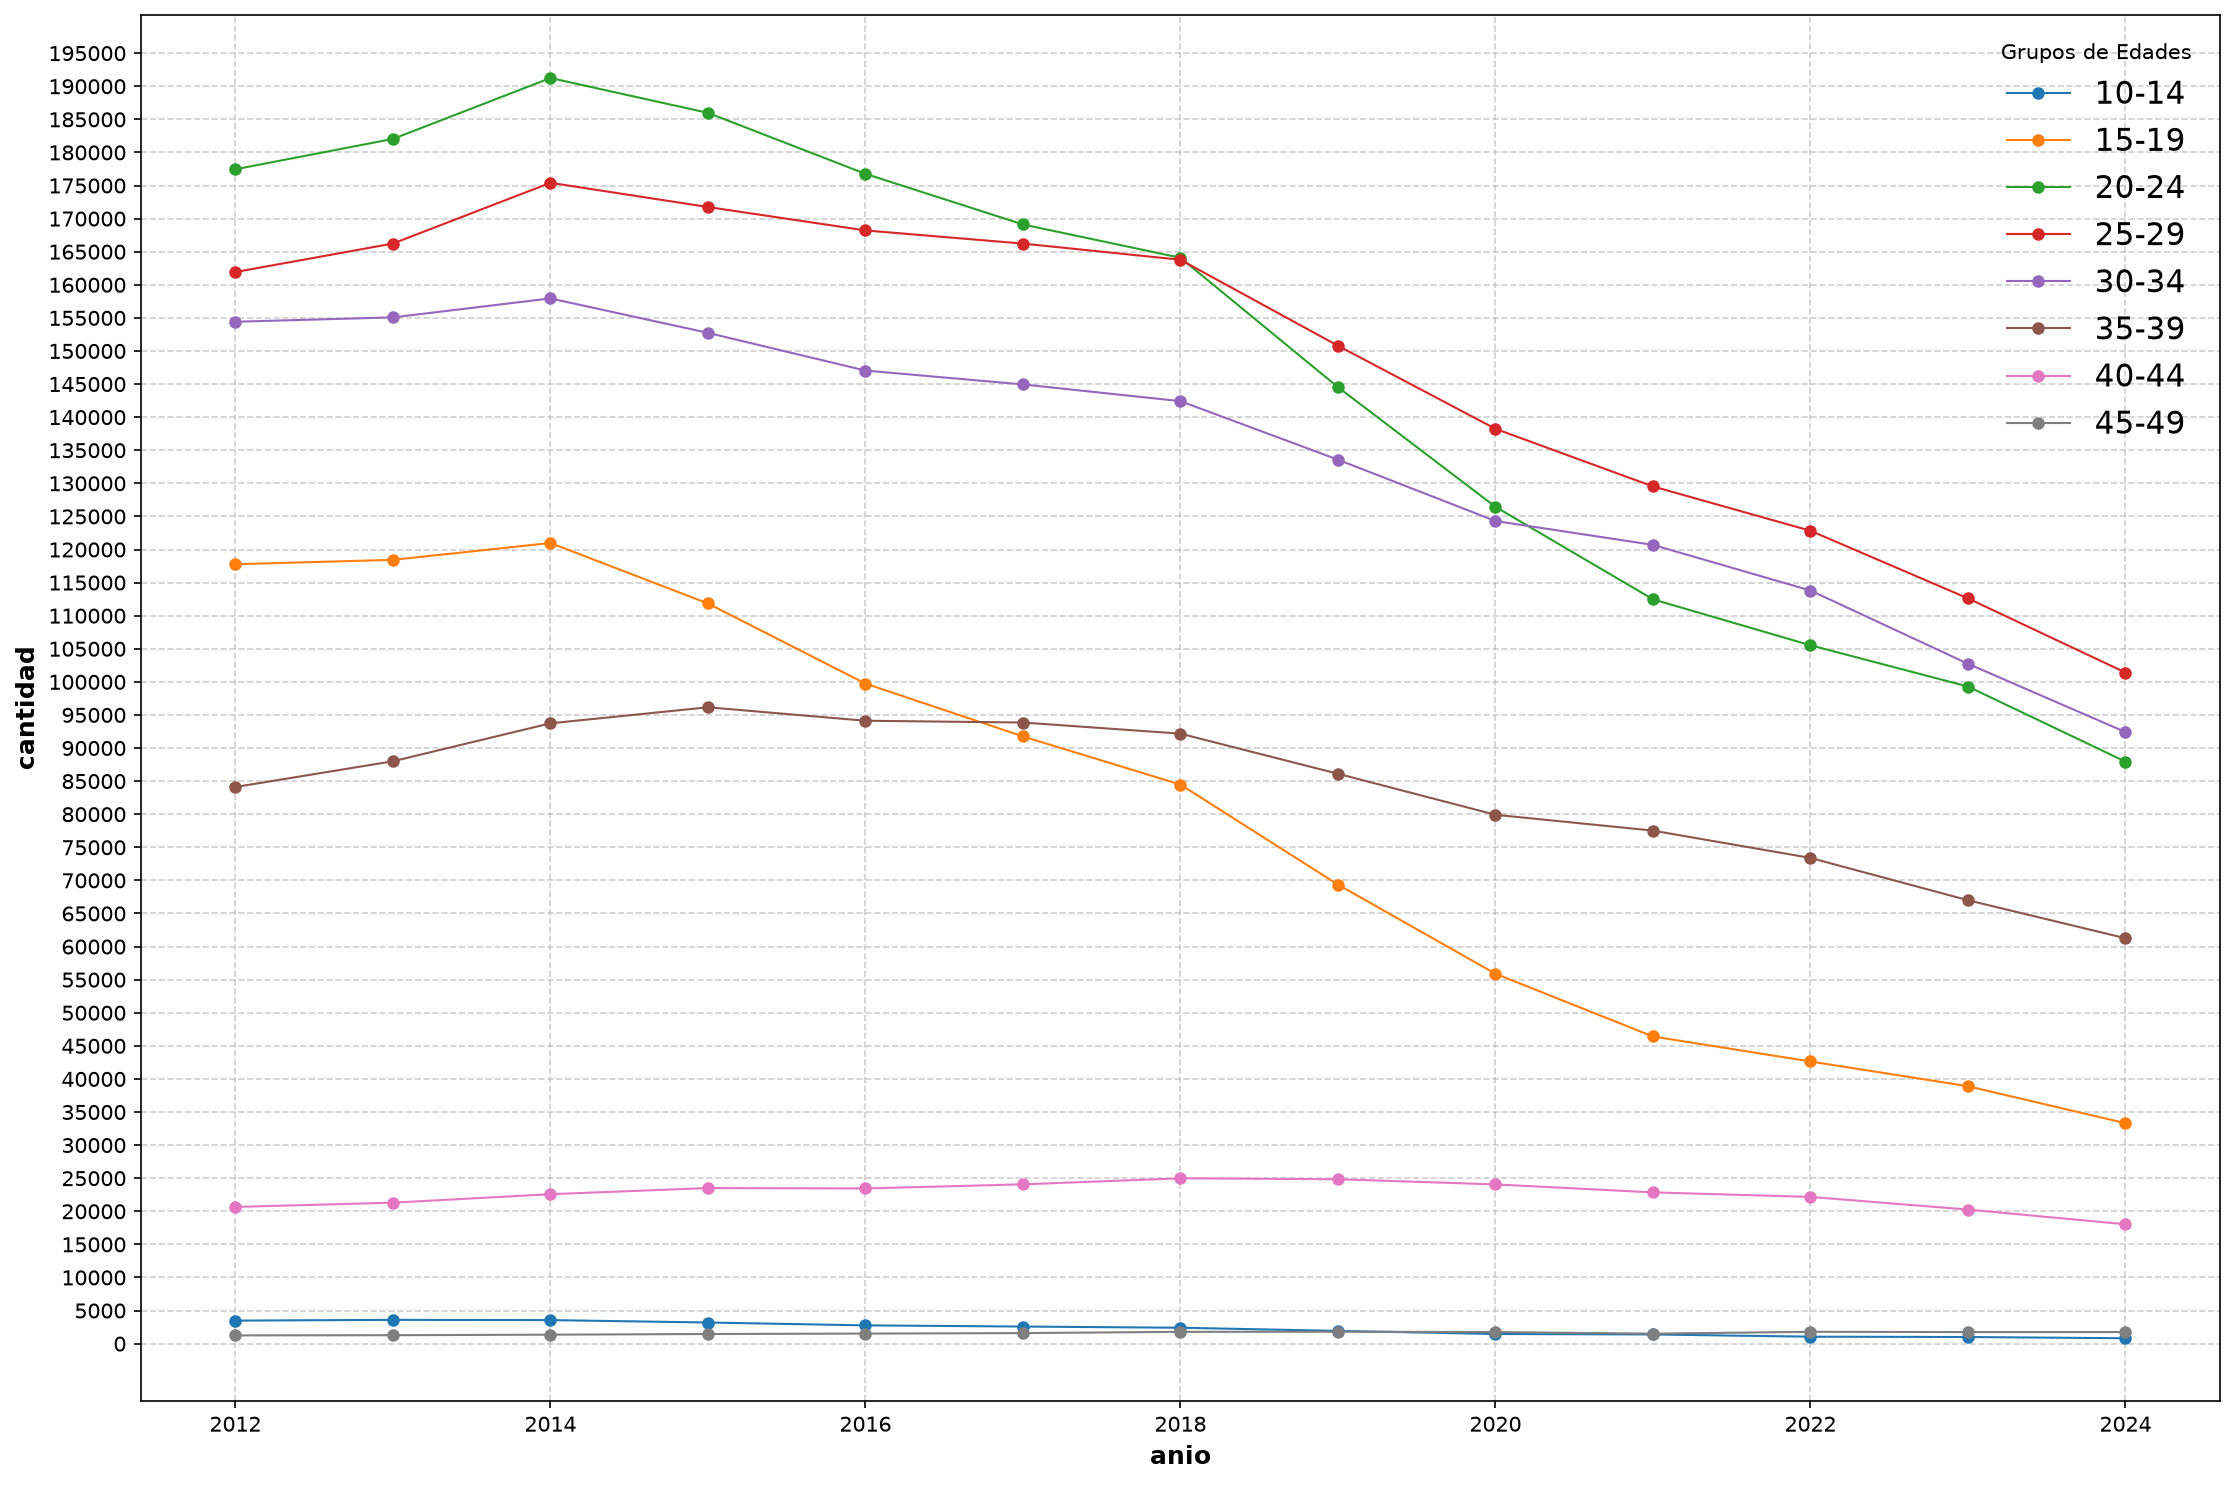

In [29]:
madres_grupo_edad_total = (nacimientos_madres.groupby(['anio','grupo_etario_madre'],as_index=False)['cantidad'].sum())
max_por_año= madres_grupo_edad_total.loc[madres_grupo_edad_total.groupby('grupo_etario_madre')['cantidad'].idxmax()].reset_index(drop=True)

plt.figure(figsize=(15,10),dpi=150)
for grupo, df_grupo in madres_grupo_edad_total.groupby('grupo_etario_madre'):
    plt.plot(df_grupo['anio'], df_grupo['cantidad'], label=grupo, marker='o',markersize=5, linewidth=1)

val_min = int(madres_grupo_edad_total['cantidad'].min())
val_max = int(madres_grupo_edad_total['cantidad'].max())
paso = 5000
plt.yticks(range(0, val_max + paso, paso))

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel('anio',fontsize=12, fontweight='bold')
plt.ylabel('cantidad',fontsize=12, fontweight='bold')
plt.legend(title='Grupos de Edades', bbox_to_anchor=(1, 1), frameon=False, fontsize=15)
plt.tight_layout()
plt.show()


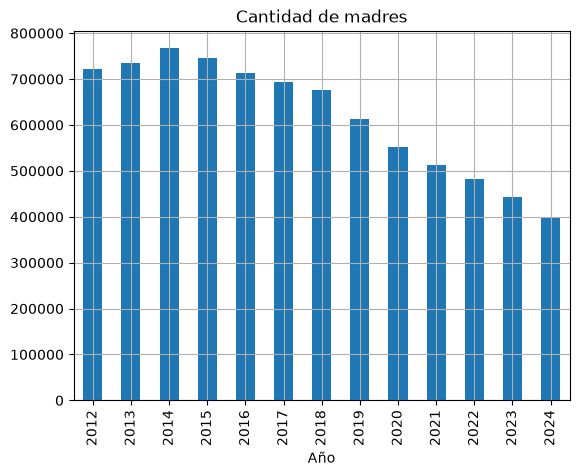

In [30]:
madres_total_año = nacimientos_madres.groupby('anio')['cantidad'].sum().plot(kind='bar', grid=True, title='Cantidad de madres', xlabel='Año')

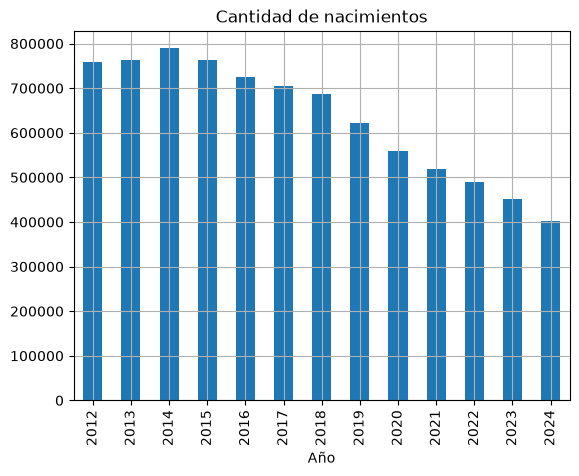

In [31]:
nacimientos_total_año = nacimientos.groupby('anio')['nacimientos'].sum().plot(kind='bar', grid=True, title='Cantidad de nacimientos', xlabel='Año')